# Prepare the data

In [1]:
ls -lh /app/data/custom_data_1/

total 13G
-rwxrwxrwx 1 1018 1018 517M Jul 17 13:17 ERA5-20250716T095623Z-1-001.zip*
drwxrwxrwx 2 root root 4.0K Jul 22 11:40 ERA5_preprocessed/
drwxrwxrwx 3 root root 4.0K Aug  5 08:50 ERA5_wrf_combined/
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:13 WRF-20250716T095739Z-1-001.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:15 WRF-20250716T095739Z-1-002.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:14 WRF-20250716T095739Z-1-003.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:17 WRF-20250716T095739Z-1-004.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:16 WRF-20250716T095739Z-1-005.zip*
-rwxrwxrwx 1 root root 2.3G Jul 31 13:13 custom_concat_train.nc*
drwxrwxrwx 4 root root 4.0K Jul 17 13:30 unziped/


## Unzip the files

In [ ]:
#! apt-get update && apt-get install -y unzip

In [ ]:
#%%sh 
#for file in /app/data/custom_data_1/*.zip; do unzip "$file" -d /app/data/custom_data_1/unziped; done

## Interpolate

In [ ]:
import os
import xarray as xr
import numpy as np
from glob import glob
from scipy.interpolate import griddata
from scipy.interpolate import RectBivariateSpline

from utils.interp_era5_to_wrf import process_date

ERA5_DIR = "/app/data/custom_data_1/unziped/ERA5/"  # Folder with both pressure and single level files
WRF_DIR = "/app/data/custom_data_1/unziped/WRF/"
OUT_DIR = "/app/data/custom_data_1/ERA5_preprocessed/"
LEVELS = [500, 850]  # hPa
VARIABLES = ["t", "z", "u", "v"]  # From pressure level file
SINGLE_VARS = ["u10", "v10", "d2m", "t2m", "sst", "skt", "sp", "tcwv", "tp", "q"]       # From single level file
os.makedirs(OUT_DIR, exist_ok=True)

era5_files = sorted(glob(os.path.join(ERA5_DIR, "era5_pressure_levels_cropped_*.nc")))
date_list = [os.path.basename(f).replace("era5_pressure_levels_cropped_", "").replace(".nc", "") for f in era5_files]

for date in date_list:
    process_date(date, ERA5_DIR, WRF_DIR, OUT_DIR, VARIABLES, LEVELS, SINGLE_VARS)

## Combine 

In [ ]:
import os
import glob
import json
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from utils.merge import merge_files

ERA5_DIR = "/app/data/custom_data_1/ERA5_preprocessed/"
WRF_DIR = "/app/data/custom_data_1/unziped/WRF/"
OUT_DIR = "/app/data/custom_data_1/ERA5_wrf_combined/"

os.makedirs(OUT_DIR, exist_ok=True)

merge_files(ERA5_DIR, WRF_DIR, OUT_DIR)

## Compute stats

In [ ]:
from utils.merge import compute_dataset_stats

JSON_OUT = os.path.join(OUT_DIR, "uae_stats.json")
INVARIANT_FILE = None #os.path.join(WRF_DIR, "invariants_wrf.nc")
invariant_ds = None #xr.open_dataset(INVARIANT_FILE)[["XLAT", "XLONG", "elev_mean", "lsm_mean", "land_use"]]

compute_dataset_stats(OUT_DIR, JSON_OUT, invariant_ds=invariant_ds)

## Concat

In [ ]:
from utils.concat import concat
import os

# Parameters
OUT_DIR = "/app/data/custom_data_1/ERA5_wrf_combined/"
OUTPUT_FILE = os.path.join(OUT_DIR, "custom_concat_train.nc")
MULTIPLE_OF = 8  # Can be set to 2, 4, 8, etc.
PAD_VALUE = 0  # Value to use for padding
end = -1

concat(OUT_DIR, OUTPUT_FILE, MULTIPLE_OF, PAD_VALUE, end)

# Inspect the data

In [3]:
data_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"

In [4]:
import netCDF4 as nc

# Open the file and list all groups
with nc.Dataset(data_path) as f:
    print("Groups in the file:", list(f.groups.keys()))

Groups in the file: ['input', 'output']


In [6]:
import xarray as xr
# Dynamically inspect the dataset to find input variables
ds = xr.open_dataset(data_path)
ds

<xarray.Dataset> Size: 35kB
Dimensions:  (sample: 2160, coord: 2)
Coordinates:
    coord    (sample, coord) float32 17kB ...
Dimensions without coordinates: sample
Data variables:
    time     (sample) datetime64[ns] 17kB ...

In [8]:
input_group = xr.open_dataset(data_path, group="input")
input_group

<xarray.Dataset> Size: 29GB
Dimensions:  (sample: 2160, y_lr: 448, x_lr: 448)
Dimensions without coordinates: sample, y_lr, x_lr
Data variables: (12/17)
    t_850    (sample, y_lr, x_lr) float32 2GB ...
    t_500    (sample, y_lr, x_lr) float32 2GB ...
    z_850    (sample, y_lr, x_lr) float32 2GB ...
    z_500    (sample, y_lr, x_lr) float32 2GB ...
    u_850    (sample, y_lr, x_lr) float32 2GB ...
    u_500    (sample, y_lr, x_lr) float32 2GB ...
    ...       ...
    d2m      (sample, y_lr, x_lr) float32 2GB ...
    skt      (sample, y_lr, x_lr) float32 2GB ...
    sst      (sample, y_lr, x_lr) float32 2GB ...
    sp       (sample, y_lr, x_lr) float32 2GB ...
    tcwv     (sample, y_lr, x_lr) float32 2GB ...
    tp       (sample, y_lr, x_lr) float32 2GB ...

In [23]:
output_group = xr.open_dataset(data_path, group="output")
output_group

<xarray.Dataset> Size: 14GB
Dimensions:    (sample: 2160, y_hr: 448, x_hr: 448)
Dimensions without coordinates: sample, y_hr, x_hr
Data variables:
    T2         (sample, y_hr, x_hr) float32 2GB ...
    U10        (sample, y_hr, x_hr) float32 2GB ...
    V10        (sample, y_hr, x_hr) float32 2GB ...
    rain_rate  (sample, y_hr, x_hr) float32 2GB ...
    SST        (sample, y_hr, x_hr) float32 2GB ...
    TSK        (sample, y_hr, x_hr) float32 2GB ...
    Q2         (sample, y_hr, x_hr) float32 2GB ...
    PSFC       (sample, y_hr, x_hr) float32 2GB ...

In [12]:
! cat /app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json

{
    "input": {
      "t_850": {
        "mean": 290.9084777832031,
        "std": 5.257435321807861
      },
      "t_500": {
        "mean": 264.5926513671875,
        "std": 3.2524030208587646
      },
      "z_850": {
        "mean": 14884.498046875,
        "std": 251.68234252929688
      },
      "z_500": {
        "mean": 57202.86328125,
        "std": 511.24945068359375
      },
      "u_850": {
        "mean": 2.6370012760162354,
        "std": 4.263711929321289
      },
      "u_500": {
        "mean": 17.538833618164062,
        "std": 9.499774932861328
      },
      "v_850": {
        "mean": -0.7689204812049866,
        "std": 4.730744361877441
      },
      "v_500": {
        "mean": -0.5210968255996704,
        "std": 5.03557014465332
      },
      "u10": {
        "mean": 0.33105266094207764,
        "std": 2.99322509765625
      },
      "v10": {
        "mean": -0.7627664804458618,
        "std": 3.2931952476501465
      },
      "t2m": {
        "mean": 298.06152

# Train regression

examples/weather/corrdiff/conf/config_training_custom_regression.yaml

In [7]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.hp.lr=0.01 \
    --config-name=config_training_custom_regression

W0807 14:04:49.570173 1127 torch/distributed/run.py:766] 
W0807 14:04:49.570173 1127 torch/distributed/run.py:766] *****************************************
W0807 14:04:49.570173 1127 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0807 14:04:49.570173 1127 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https://hy

# Train Diffusion

examples/weather/corrdiff/conf/config_training_custom_diffusion.yaml

In [2]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.io.regression_checkpoint_path="/app/checkpoints_regression/UNet.0.180000.mdlus" \
    --config-name=config_training_custom_diffusion --cfg job

W0813 06:40:10.516287 88 torch/distributed/run.py:766] 
W0813 06:40:10.516287 88 torch/distributed/run.py:766] *****************************************
W0813 06:40:10.516287 88 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0813 06:40:10.516287 88 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydra.cc/doc

In [1]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.io.regression_checkpoint_path="/app/checkpoints_regression/UNet.0.180000.mdlus" \
    --config-name=config_training_custom_diffusion

W0813 11:25:34.511166 1732 torch/distributed/run.py:766] 
W0813 11:25:34.511166 1732 torch/distributed/run.py:766] *****************************************
W0813 11:25:34.511166 1732 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0813 11:25:34.511166 1732 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydr

# Prediction

In [2]:
ls -lh /app/outputs/checkpoints_diffusion/

total 4.9G
-rw-r--r-- 1 root root 44M Aug 13 06:54 EDMPrecondSuperResolution.0.1000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:32 EDMPrecondSuperResolution.0.10000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:35 EDMPrecondSuperResolution.0.10504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:37 EDMPrecondSuperResolution.0.11000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:39 EDMPrecondSuperResolution.0.11504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:41 EDMPrecondSuperResolution.0.12000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:43 EDMPrecondSuperResolution.0.12504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:45 EDMPrecondSuperResolution.0.13000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:47 EDMPrecondSuperResolution.0.13504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:50 EDMPrecondSuperResolution.0.14000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:52 EDMPrecondSuperResolution.0.14504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:54 EDMPrecondSuperResolution.0.15000.mdlus
-rw-r--r-- 1 root root 44M Aug

## Load model

In [44]:
import os
import torch
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution
from physicsnemo.launch.utils.checkpoint import load_checkpoint

# Paths configuration
checkpoint_dir = "/app/outputs/checkpoints_diffusion"  # Directory where model checkpoints are stored
checkpoint_index = 9504  # Specific checkpoint number to load (from training logs)

# Model Initialization Parameters
# These arguments come from the training config YAML file
model_args = {
    # Number of additional grid channels for positional/conditional information
    # From model_args.N_grid_channels in training config
    "N_grid_channels": 4,
    
    # Type of positional embedding grid (sinusoidal, learned, etc.)
    # From model_args.gridtype in training config
    "gridtype": "sinusoidal",
    
    # Type of embedding for diffusion timesteps/noise levels
    # From model_args.embedding_type in training config
    "embedding_type": "zero",
    
    # Base number of channels in the model (scaled by channel_mult)
    # From model_args.model_channels in training config
    "model_channels": 64,
    
    # Channel multipliers for different resolution levels
    # [1, 2, 2] means: 64, 128, 128 channels at different resolutions
    # From model_args.channel_mult in training config
    "channel_mult": [1, 2, 2],
    
    # Resolutions at which to apply attention layers
    # From model_args.attn_resolutions in training config
    "attn_resolutions": [16],
    
    # Minimum noise level for diffusion process
    # Default value for EDM framework
    "sigma_min": 0.0,
    
    # Maximum noise level for diffusion process
    # Default value for EDM framework
    "sigma_max": 1.0,
    
    # Data standard deviation scaling factor
    # Default value for EDM framework
    "sigma_data": 0.5,
    
    # Type of UNet architecture being used
    # From model_args.model_type in training config
    "model_type": "SongUNetPosEmbd",
}

# Create the EDM Super-Resolution model
model = EDMPrecondSuperResolution(
    # Input image resolution (448x448)
    # Should match the resolution used during training
    img_resolution=448,
    
    # Number of input channels:
    # - 14: From input_variables in dataset config (t_850, t_500, z_850, etc.)
    # - 4: From N_grid_channels (positional/conditional information)
    # - 4: Likely from hr_mean_conditioning (2 output vars × 2 for mean/std)
    # Total = 22 channels (14 + 4 + 4)
    img_in_channels=22,
    
    # Number of output channels:
    # - 2: Matches output_variables in dataset config (U10, V10)
    img_out_channels=2,
    
    # Pass all other model configuration parameters
    **model_args,
)

# Load the pre-trained checkpoint
epoch = load_checkpoint(
    path=checkpoint_dir,  # Directory containing checkpoints
    models=model,        # Model to load weights into
    epoch=checkpoint_index,  # Checkpoint number to load
    device="cuda",       # Load onto GPU (use "cpu" if no GPU available)
    # strict=False       # Uncomment to ignore mismatched keys (not recommended)
)

print(f"Model loaded successfully from epoch {epoch}")

# Set the model to evaluation mode (important for inference)
model.eval()

Model loaded successfully from epoch 9504


EDMPrecondSuperResolution(
  (model): SongUNetPosEmbd(
    (enc): ModuleDict(
      (448x448_conv): Conv2d()
      (448x448_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (448x448_block1): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (448x448_block2): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (448x448_block3): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (224x224_down): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
 

## Inspect model

In [38]:
import inspect
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution

# Print the forward method signature
print(inspect.signature(EDMPrecondSuperResolution.forward))

# Or for more details:
print(inspect.getsource(EDMPrecondSuperResolution.forward))

(self, x: torch.Tensor, img_lr: torch.Tensor, sigma: torch.Tensor, force_fp32: bool = False, **model_kwargs: dict) -> torch.Tensor
    def forward(
        self,
        x: torch.Tensor,
        img_lr: torch.Tensor,
        sigma: torch.Tensor,
        force_fp32: bool = False,
        **model_kwargs: dict,
    ) -> torch.Tensor:
        """
        Forward pass of the EDMPrecondSuperResolution model wrapper.

        This method applies the EDM preconditioning to compute the denoised image
        from a noisy high-resolution image and low-resolution conditioning image.

        Parameters
        ----------
        x : torch.Tensor
            Noisy high-resolution image of shape (B, C_hr, H, W). The number of
            channels `C_hr` should be equal to `img_out_channels`.
        img_lr : torch.Tensor
            Low-resolution conditioning image of shape (B, C_lr, H, W). The number
            of channels `C_lr` should be equal to `img_in_channels`.
        sigma : torch.Tensor

In [42]:
import torch

# Correct channel dimensions accounting for positional embeddings
batch_size = 1
main_channels = 18 # 16+2
hr_channels = 2  # U10/V10 output
height = width = 448

# Create properly sized dummy tensors
dummy_x = torch.randn(batch_size, hr_channels, height, width)  # High-res (2 channels)
dummy_img_lr = torch.randn(batch_size, main_channels, height, width)  # Low-res (18 channels)
sigma = torch.tensor([1.0])  # Noise level

# Run inference
with torch.no_grad():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dummy_x = dummy_x.to(device)
    dummy_img_lr = dummy_img_lr.to(device)
    model = model.to(device)
    sigma = sigma.to(device)
    
    try:
        output = model(x=dummy_x, img_lr=dummy_img_lr, sigma=sigma)
        print("Success! Output shape:", output.shape)
    except Exception as e:
        print("Failed:", str(e))

Success! Output shape: torch.Size([1, 2, 448, 448])


## Test inference

/app/physicsnemo/models/diffusion/layers.py:712: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


U10 Prediction vs Ground Truth:
Pred mean: -0.9048, True mean: -1.1625
Pred std: 1.1283, True std: 1.6635

V10 Prediction vs Ground Truth:
Pred mean: -1.2105, True mean: 1.6532
Pred std: 0.8714, True std: 1.7198


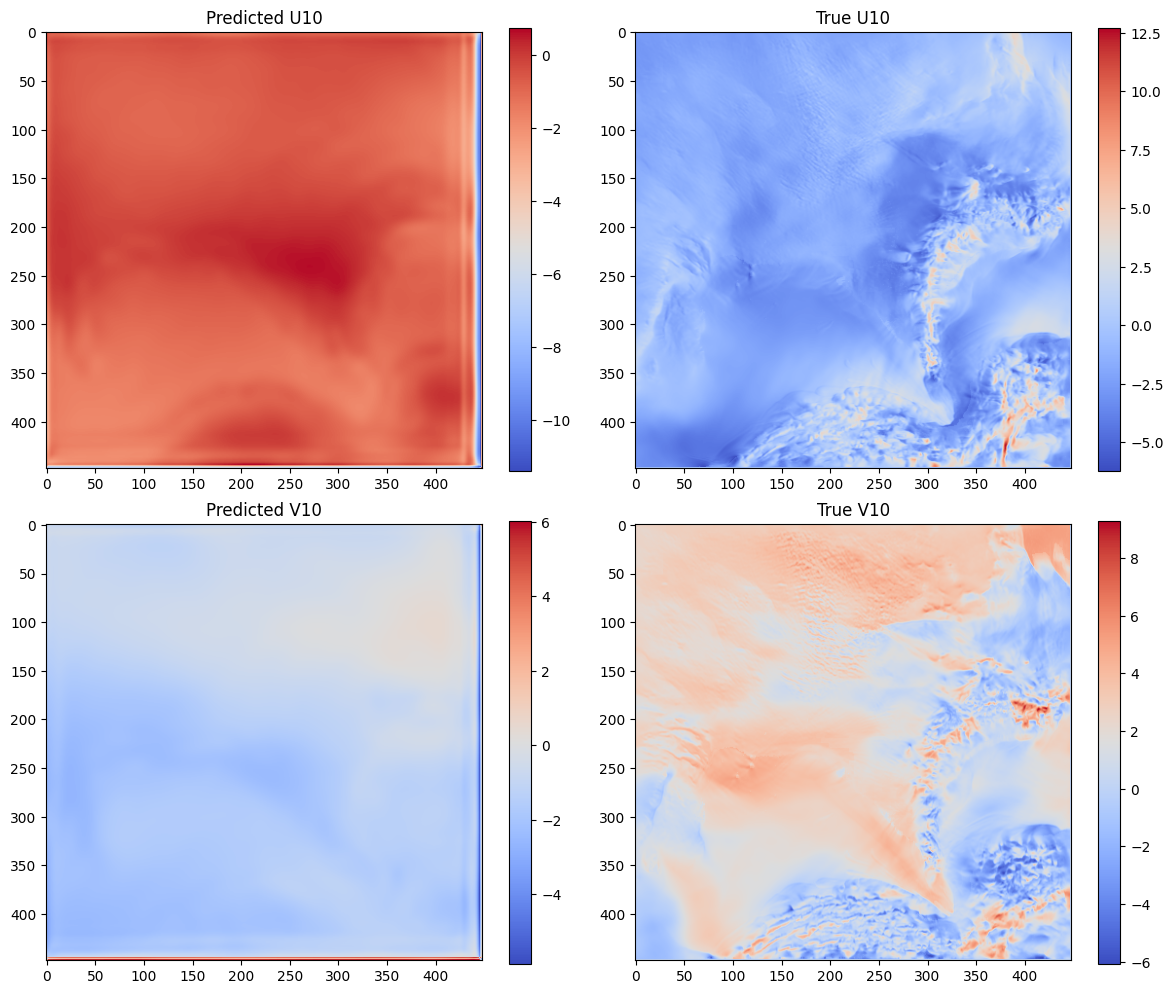

In [47]:
import xarray as xr
import torch
import numpy as np
import json
import matplotlib.pyplot as plt

# 1. Load and prepare input data
data_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"
stats_path = "/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json"

# Open the dataset
input_group = xr.open_dataset(data_path, group="input")
output_group = xr.open_dataset(data_path, group="output")

# Select the first sample for inference
sample_idx = 0
input_data = input_group.isel(sample=sample_idx)
output_data = output_group.isel(sample=sample_idx)

# 2. Normalization functions
def normalize(data, var_name, stats):
    mean = stats["input"][var_name]["mean"]
    std = stats["input"][var_name]["std"]
    return (data - mean) / std

def denormalize(data, var_name, stats):
    mean = stats["output"][var_name]["mean"]
    std = stats["output"][var_name]["std"]
    return (data * std) + mean

# Load stats
with open(stats_path) as f:
    stats = json.load(f)

# 3. Prepare input variables (all 18 total channels)
selected_vars = [
    't_850', 't_500', 'z_850', 'z_500',  # 4 variables
    'u_850', 'u_500', 'v_850', 'v_500',  # +4 = 8
    'u10', 'v10', 't2m', 'd2m',          # +4 = 12
    "skt", "sp", "tcwv", "tp"            # +4 = 16
]

# Stack and normalize input variables
input_stack = []
for var in selected_vars:
    var_data = input_data[var].values
    var_norm = normalize(var_data, var, stats)
    input_stack.append(var_norm)

input_array = np.stack(input_stack, axis=0)  # Shape: (16, 448, 448)
input_tensor = torch.from_numpy(input_array).float().unsqueeze(0)  # (1, 16, 448, 448)

# 4. Prepare grid channels (4 channels as per config)
# grid_channels = torch.zeros(1, 4, 448, 448)  # Batch of 4 grid channels

# 5. Prepare conditioning (2 channels - means of U10/V10 only)
conditioning = torch.zeros(1, 2, 448, 448)
conditioning[:, 0] = stats["output"]["U10"]["mean"]  # U10 mean
conditioning[:, 1] = stats["output"]["V10"]["mean"]  # V10 mean

# 6. Combine all inputs (16 vars + 2 conditioning = 18 channels) + 4 grid are not added 
# The model will add 6 positional channels internally (18 + 6 = 24)
# low_res_input = torch.cat([input_tensor, grid_channels, conditioning], dim=1)
low_res_input = torch.cat([input_tensor, conditioning], dim=1)

# 7. Prepare high-res input (2 channels of zeros as initial guess)
high_res_input = torch.zeros(1, 2, 448, 448)  # For U10/V10 output

# 8. Run inference
with torch.no_grad():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    high_res_input = high_res_input.to(device)
    low_res_input = low_res_input.to(device)
    model = model.to(device)
    
    # Prepare noise level (sigma)
    sigma = torch.tensor([1.0], device=device)
    
    # Perform inference with properly separated inputs
    output = model(
        x=high_res_input,      # High-res input [1, 2, 448, 448]
        img_lr=low_res_input,  # Low-res input [1, 18, 448, 448]
        sigma=sigma
    )
    
    # Convert output to numpy
    output = output.cpu().numpy()

# 9. Process output (U10 and V10)
u10_pred = output[0, 0]  # First output channel
v10_pred = output[0, 1]  # Second output channel

u10_denorm = denormalize(u10_pred, "U10", stats)
v10_denorm = denormalize(v10_pred, "V10", stats)

# 10. Get ground truth
u10_true = output_data["U10"].values
v10_true = output_data["V10"].values

# 11. Print comparison
print("U10 Prediction vs Ground Truth:")
print(f"Pred mean: {u10_denorm.mean():.4f}, True mean: {u10_true.mean():.4f}")
print(f"Pred std: {u10_denorm.std():.4f}, True std: {u10_true.std():.4f}")

print("\nV10 Prediction vs Ground Truth:")
print(f"Pred mean: {v10_denorm.mean():.4f}, True mean: {v10_true.mean():.4f}")
print(f"Pred std: {v10_denorm.std():.4f}, True std: {v10_true.std():.4f}")

# 12. Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# U10 plots
im = axes[0,0].imshow(u10_denorm, cmap='coolwarm')
axes[0,0].set_title("Predicted U10")
plt.colorbar(im, ax=axes[0,0])

im = axes[0,1].imshow(u10_true, cmap='coolwarm')
axes[0,1].set_title("True U10")
plt.colorbar(im, ax=axes[0,1])

# V10 plots
im = axes[1,0].imshow(v10_denorm, cmap='coolwarm')
axes[1,0].set_title("Predicted V10")
plt.colorbar(im, ax=axes[1,0])

im = axes[1,1].imshow(v10_true, cmap='coolwarm')
axes[1,1].set_title("True V10")
plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()

In [74]:
import os
import torch
import xarray as xr
import netCDF4 as nc
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution
from physicsnemo.models.diffusion.preconditioning import EDMPrecond
from physicsnemo.launch.utils.checkpoint import load_checkpoint
from physicsnemo.utils.corrdiff.utils import NetCDFWriter

# Paths
checkpoint_dir = "/app/outputs/checkpoints_diffusion"
checkpoint_name = "EDMPrecondSuperResolution"  # Ensure this matches the actual file name
checkpoint_index = 9504  # Replace with the desired checkpoint index
data_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"
output_netcdf_path = "/app/data/custom_data_1/predictions.nc"

# Open the dataset and inspect groups
with nc.Dataset(data_path) as f:
    print("Groups in the file:", list(f.groups.keys()))

# Load the input group
input_group = xr.open_dataset(data_path, group="input")
print(f"Available variables in the input group: {list(input_group.variables.keys())}")

# Dynamically select input variables
input_variable_name = "t_850"  # Replace with a valid variable name from the input group
if input_variable_name not in input_group.variables:
    raise KeyError(f"Variable '{input_variable_name}' not found in the input group. Available variables: {list(input_group.variables.keys())}")

# Load the output group
output_group = xr.open_dataset(data_path, group="output")
print(f"Available variables in the output group: {list(output_group.variables.keys())}")

# Dynamically select output variables
output_variable_names = ["U10", "V10"]  # Replace with valid variable names from the output group
for var in output_variable_names:
    if var not in output_group.variables:
        raise KeyError(f"Variable '{var}' not found in the output group. Available variables: {list(output_group.variables.keys())}")

# Initialize the model
model = EDMPrecondSuperResolution(
    img_resolution=input_group[input_variable_name].shape[-1],  # Automatically infer resolution
    img_in_channels=1,  # Assuming 1 channel for low-resolution input
    img_out_channels=len(output_variable_names),  # Number of output channels
    sigma_min=0.0,
    sigma_max=1.0,
    sigma_data=0.5,
    model_type="SongUNetPosEmbd",  # Replace with the correct model type
)
        # "SongUNetPosEmbd",
        # "SongUNetPosLtEmbd",
        # "SongUNet",
        # "DhariwalUNet",

# Load the checkpoint
checkpoint_path = os.path.join(checkpoint_dir, f"{checkpoint_name}.0.{checkpoint_index}.mdlus")
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")

# Use the directory path for load_checkpoint
epoch = load_checkpoint(
    path=checkpoint_dir,  # Pass the directory path
    models=model,
    epoch=checkpoint_index,  # Specify the checkpoint index
    device="cuda",  # Use "cpu" if GPU is not available
)

print(f"Model loaded successfully from epoch {epoch}")

# Set the model to evaluation mode
model.eval()

# Load input data
input_data = input_group[input_variable_name].values
lat = input_group["y_lr"].values if "y_lr" in input_group.dims else None
lon = input_group["x_lr"].values if "x_lr" in input_group.dims else None
if lat is None or lon is None:
    raise KeyError("Latitude ('y_lr') and/or longitude ('x_lr') dimensions not found in the input group.")

# Prepare NetCDFWriter
output_channels = [{"name": var, "level": ""} for var in output_variable_names]
with nc.Dataset(output_netcdf_path, "w", format="NETCDF4") as ncfile:
    writer = NetCDFWriter(
        f=ncfile,
        lat=lat,
        lon=lon,
        input_channels=[{"name": input_variable_name, "level": ""}],
        output_channels=output_channels,
    )

    # Generate predictions and write to NetCDF
    for time_index in range(input_data.shape[0]):  # Iterate over time steps
        input_sample = torch.tensor(input_data[time_index], dtype=torch.float32).unsqueeze(0).cuda()
        low_res_sample = input_sample.clone()  # Assuming low-resolution input is derived from the same data

        with torch.no_grad():
            prediction = model(
                x=input_sample,
                img_lr=low_res_sample,
                sigma=torch.tensor([0.5]).cuda(),  # Example sigma value
            ).cpu().numpy()

        # Write input, prediction, and time to NetCDF
        writer.write_input(input_variable_name, time_index, input_data[time_index])
        for i, var in enumerate(output_variable_names):
            writer.write_prediction(var, time_index, 0, prediction[0, i])
        writer.write_time(time_index, input_group["time"].values[time_index])

print(f"NetCDF file generated at {output_netcdf_path}")

Groups in the file: ['input', 'output']
Available variables in the input group: ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sst', 'sp', 'tcwv', 'tp']
Available variables in the output group: ['T2', 'U10', 'V10', 'rain_rate', 'SST', 'TSK', 'Q2', 'PSFC']


Could not find valid model file /app/outputs/checkpoints_diffusion/EDMPrecondSuperResolution.0.9549.mdlus, skipping load
Could not find valid checkpoint file, skipping load


Model loaded successfully from epoch 0


ValueError: not enough values to unpack (expected 2, got 1)